# Color to Grayscale Conversion & Multi-Format File-Size Comparison

### Grayscale Conversion Formula (ITU-R BT.601):

$$\text{Gray} = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$

In OpenCV (where color channel order is BGR):

$$\text{Gray} = 0.114 \cdot B + 0.587 \cdot G + 0.299 \cdot R$$

This notebook:

1. Reads a color image from disk with `cv2.imread()`.
2. Displays image properties (shape, dtype, total pixel count).
3. Converts color to grayscale and displays side-by-side using `matplotlib`.
4. Encodes grayscale image in PNG, JPEG (quality=50), and BMP formats.
5. Compares file sizes across different formats.
6. Analyzes compression mechanisms (lossless vs. lossy vs. uncompressed).


In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

## (i) Read Color Image


In [4]:
def load_color_image(path: str = "images/image1.jpg") -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)

    return img


img_color = load_color_image("images/image1.jpg")

## (ii) Print Image Properties (Shape, Dtype, Total Pixel Count)


In [5]:
h, w = img_color.shape[:2]
total_pixels = h * w
print(f"Shape        : {img_color.shape}   (height, width, channels)")
print(f"Dtype        : {img_color.dtype}")
print(f"Total pixels : {total_pixels}  ({h} x {w})")

Shape        : (640, 612, 3)   (height, width, channels)
Dtype        : uint8
Total pixels : 391680  (640 x 612)


## (iii) Convert to Grayscale & Display Side by Side


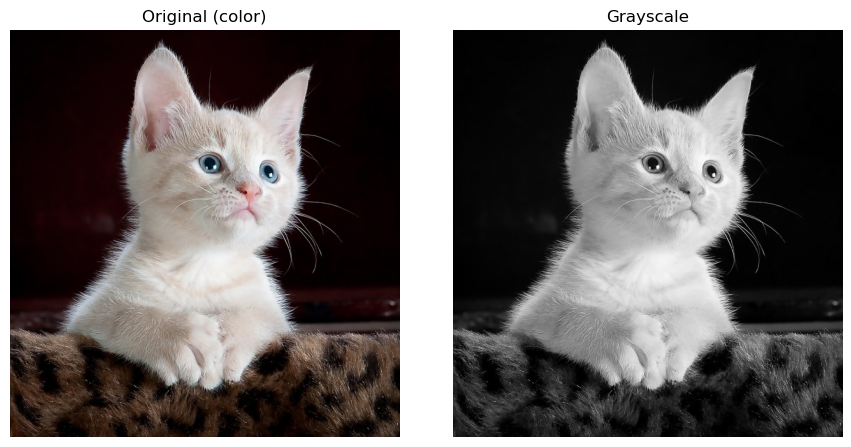

In [6]:
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
# cv2 loads BGR; convert to RGB for correct matplotlib display
axes[0].imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original (color)")
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Grayscale")
axes[1].axis("off")

fig.tight_layout()
plt.show()

## (iv) & (v) Multi-Format Image Encoding & File Size Comparison


In [7]:
# Encode image into byte buffers to measure format sizes without saving files to disk
_, png_buf = cv2.imencode(".png", img_gray)
_, jpg_buf = cv2.imencode(".jpg", img_gray, [cv2.IMWRITE_JPEG_QUALITY, 50])
_, bmp_buf = cv2.imencode(".bmp", img_gray)

sizes = {
    "PNG": len(png_buf),
    "JPG (q=50)": len(jpg_buf),
    "BMP": len(bmp_buf),
}

print(f"{'Format':<12}{'Bytes':>10}{'KB':>10}")
print("-" * 32)
for fmt, size in sizes.items():
    print(f"{fmt:<12}{size:>10}{size / 1024:>10.2f}")

smallest = min(sizes, key=sizes.get)
largest = max(sizes, key=sizes.get)
print(f"\nSmallest format: {smallest} ({sizes[smallest]} bytes)")
print(f"Largest format : {largest} ({sizes[largest]} bytes)")

Format           Bytes        KB
--------------------------------
PNG             192432    187.92
JPG (q=50)       30766     30.04
BMP             392758    383.55

Smallest format: JPG (q=50) (30766 bytes)
Largest format : BMP (392758 bytes)


## (vi) Discussion: Format Comparison & Compression Mechanisms

**Smallest file:** `JPG (q=50)` | **Largest file:** `BMP`

- **JPG (JPEG)** is typically the smallest format because it uses **lossy compression**. At quality=50, it aggressively discards high-frequency spatial details that the human eye is less sensitive to, trading a small amount of visual quality for a significantly smaller file size.
- **PNG** uses **lossless compression** (DEFLATE algorithm based on LZ77 and Huffman coding). It preserves every single pixel value with 100% fidelity, making it smaller than uncompressed formats but larger than lossy JPEG.
- **BMP** is an **uncompressed** format (storing raw pixel array data plus header metadata). It grows strictly linearly with image resolution ($H \times W \times \text{bytes per pixel}$), regardless of image content, making it the largest file of the three.
